# Linear Model (Classification) MCMC
Part of the Bayesian neural networks via MCMC: a Python-based tutorial

This section of the tutorial covers the development of an MCMC algorithm applied to a simple linear model for classification problems.

### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, fixed, widgets
# visulisation function
from functions.visualisations import (
    histogram_trace, plot_confusion_matrix, boxplot_weights
)

from types import MethodType

np.random.seed(2023)

## Define a class with the functions and attributes required for a linear model

- `predict`: Function to output y given the input data and model parameters - $y = w x + b$
- `evaluate_proposal`: Function to load a given proposal distribution ($\theta$) and return the model prediction
- `encode`: Helper function to encode the model parameters ($\theta$) into the model as $w$ and $b$

In [2]:
class LinearModel:
    '''
    Simple linear model with a single output (y) given the covariates x_1...x_M of the form:
    y = w_1 * x_1 + ... + w_M * x_M + b
    where M = number of features, w are the weights, and b is the bias.
    '''
    # Initialise values of model parameters
    def __init__(self, layer_sizes):
        self.w = None
        self.b = None        
        self.input_num = layer_sizes[0]
        self.output_num = layer_sizes[-1] 
        self.n_params = (self.input_num * self.output_num) + self.output_num

    # Function to take in data and parameter sample and return the prediction
    def evaluate_proposal(self, data, theta):
        '''
        Encode the proposed parameters and then use the model to predict
        Input:
            data: (N x M) array of data
            theta: (M + 1) vector of parameters. The last element of theta consitutes the bias term (giving M + 1 elements)
        '''
        self.encode(theta)  # method to encode w and b
        prediction = self.predict(data) # predict and return
        probs = self.softmax(prediction)
        prediction = np.argmax(probs, axis=1)
        return prediction, probs

    # Linear model prediction
    def predict(self, x_in):
        y_out = x_in.dot(self.w) + self.b 
        return y_out
    
    # Helper function to split the parameter vector into w and band store in the model
    def encode(self, theta):
        self.w =  np.reshape(theta[:-self.output_num], (-1, self.output_num))
        self.b = theta[-self.output_num:] 

    # helper function for softmax
    def softmax(self, x):
        '''
        Implentation of the softmax function
        '''
        prob = np.exp(x) / np.sum(np.exp(x))
        return prob
  

## Define a class for the MCMC sampling

$y=f\left(x,\theta\right)+e \qquad e \sim N\left(0,\tau^2\right)$

First we will define the likelihood and prior functions

In [3]:
# Define the likelihood function
def likelihood_function(self, theta, test=False):
    '''
    Calculate the likelihood of the data given the parameters
    Input:
        theta: (M + 1) vector of parameters. The last element of theta consitutes the bias term (giving M + 1 elements)
    Output:
        log_likelihood: log likelihood of the data given the parameters
        model_prediction: prediction of the model given the parameters
        accuracy: accuracy of the model given the parameters
    '''
    # first make a prediction with parameters theta
    if test:
        x_data = self.x_test
        y_data = self.y_test
    else:
        x_data = self.x_data
        y_data = self.y_data
    model_prediction, probs = self.model.evaluate_proposal(x_data, theta)
    model_simulation = model_prediction # tausq unused for classification
    accuracy = self.accuracy(model_prediction, y_data) #Accuracy error metric 
    # now calculate the log likelihood
    log_likelihood = 0
    for ii in np.arange(x_data.shape[0]):
        for jj in np.arange(self.model.output_num):
            if y_data[ii] == jj:
                log_likelihood += np.log(probs[ii,jj])    
    return [log_likelihood, model_prediction, model_simulation, accuracy] 

# Define the prior
def prior(self, sigma_squared, theta): 
    '''
    Calculate the prior of the parameters
    Input:
        sigma_squared: variance of normal prior for theta
        theta: (M + 1) vector of parameters. The last element of theta consitutes the bias term (giving M + 1 elements)
    Output:
        log_prior: log prior
    '''
    n_params = self.theta_size # number of parameters in model
    part1 = -1 * (n_params / 2) * np.log(sigma_squared)
    part2 = 1 / (2 * sigma_squared) * (sum(np.square(theta)))
    log_prior = part1 - part2
    return log_prior

Next define the MCMC sampler

In [4]:
# MCMC sampler
def sampler(self):
    '''
    Run the sampler for a defined linear model
    '''
    ## Define empty arrays to store the sampled posterior values
    # posterior of all weights and bias over all samples
    pos_theta = np.ones((self.n_samples, self.theta_size)) 

    # record output f(x) over all samples
    pred_y = np.zeros((self.n_samples, self.x_data.shape[0]))
    # record simulated values f(x) + error over all samples 
    sim_y = np.zeros((self.n_samples, self.x_data.shape[0]))
    # record the accuracy of each sample
    accuracy_data = np.zeros(self.n_samples)
    # now for test
    test_pred_y = np.ones((self.n_samples, self.x_test.shape[0]))
    test_sim_y = np.ones((self.n_samples, self.x_test.shape[0]))
    test_accuracy_data = np.zeros(self.n_samples)

    ## Initialisation
    # initialise theta - the model parameters
    theta = np.random.randn(self.theta_size)
    # make initial prediction
    pred_y[0,], _ = self.model.evaluate_proposal(self.x_data, theta)

    # calculate the prior
    prior_val = self.prior(self.sigma_squared, theta)
    # calculate the likelihood considering observations
    [likelihood, pred_y[0,], sim_y[0,], accuracy_data[0]] = self.likelihood_function(theta)

    n_accept = 0  
    ## Run the MCMC sample for n_samples
    for ii in np.arange(1,self.n_samples):
        # Sample new values for theta using a Gaussian random walk
        theta_proposal = theta + np.random.normal(0, self.step_theta, self.theta_size)

        # calculate the prior
        prior_proposal = self.prior(
            self.sigma_squared, theta_proposal
        )
        # calculate the likelihood considering observations
        [likelihood_proposal, pred_y[ii,], sim_y[ii,], accuracy_data[ii]] = self.likelihood_function(theta_proposal)

         # calculate the test likelihood
        [_, test_pred_y[ii,], test_sim_y[ii,], test_accuracy_data[ii]] = self.likelihood_function(
            theta_proposal, test=True
        )

        # Noting that likelihood_function and prior return log likelihoods,
        # we can use log laws to calculate the acceptance probability
        diff_likelihood = likelihood_proposal - likelihood
        diff_prior = prior_proposal - prior_val

        mh_prob = min(1, np.exp(diff_likelihood + diff_prior))

        # sample to accept or reject the proposal according to the acceptance probability
        u = np.random.uniform(0, 1)
        if u < mh_prob:
            # accept and update the values
            n_accept += 1
            likelihood = likelihood_proposal
            prior_val = prior_proposal
            theta = theta_proposal
            # store to make up the posterior
            pos_theta[ii,] = theta_proposal
        else:
            # reject move and store the old values
            pos_theta[ii,] = pos_theta[ii-1,]

    # calculate the acceptance rate as a check
    accept_rate = (n_accept / self.n_samples) * 100
    print('{:.3f}% were accepted'.format(accept_rate))

    # store the posterior (samples after burn in) in a pandas dataframe and return
    self.pos_theta = pos_theta[self.n_burnin:, ]
    self.accuracy_data = accuracy_data[self.n_burnin:]

    # split theta into w and b
    results_dict = {'w{}'.format(_): self.pos_theta[:, _].squeeze() for _ in range(self.theta_size-1)}
    results_dict['b'] = self.pos_theta[:, -1].squeeze()
    results_dict['accuracy'] = self.accuracy_data.squeeze()

    # return the predictions
    pred_dict = {}
    pred_dict['train_pred'] = pred_y[self.n_burnin:,:]
    pred_dict['train_sim'] = sim_y[self.n_burnin:,:]
    pred_dict['test_pred'] = test_pred_y[self.n_burnin:,:]
    pred_dict['test_sim'] = test_sim_y[self.n_burnin:,:]

    results_df = pd.DataFrame.from_dict(
        results_dict
    )
    return results_df, pred_dict

Define a function to generate random draws from the posterior distributions

Finally combine these elements into a MCMC sampling function

In [5]:
class MCMC:
    def __init__(self, model, n_samples, n_burnin, x_data, y_data, x_test, y_test):
        self.n_samples = n_samples # number of MCMC samples
        self.n_burnin = n_burnin # number of burn-in samples
        self.x_data = x_data # (N x M)
        self.y_data = y_data # (N x 1)
        self.x_test = x_test # (Nt x num_features)
        self.y_test = y_test # (Nt x 1)

        # MCMC parameters - defines the variance term in our Gaussian random walk
        self.step_theta = 0.02;  
        
        # model hyperparameters
        # considered by looking at distribution of  similar trained  models - i.e distribution of weights and bias
        self.sigma_squared = 5

        # initisalise the linear model class
        self.model = model
        self.theta_size = self.model.n_params # weights for each feature and a bias term (M+1)

        # store output
        self.pos_theta = None
        self.accuracy_data = None

        # functions defined above - this is poor practice, but done for readability 
        # and clarity
        self.likelihood_function = MethodType(likelihood_function, self)
        self.prior = MethodType(prior, self)
        self.sampler = MethodType(sampler, self)

    # Additional error metric
    @staticmethod
    def accuracy(predictions, targets):
        '''
        Additional error metric - accuracy
        '''
        count = (predictions == targets).sum()
        return 100 * (count / predictions.shape[0])

## Load the data
- Load in the suspot data
- You can also load in the other regeression datasets `Lazer` and `Energy`

In [6]:
# load the data
name        = "Iris"
train_data   = np.loadtxt("data/{}/train.txt".format(name))
test_data    = np.loadtxt("data/{}/test.txt".format(name))

print('Training data shape: {}'.format(train_data.shape))
print('Test data shape: {}'.format(test_data.shape))

Training data shape: (105, 5)
Test data shape: (45, 5)


## Sample using MCMC

- Create the MCMC loop and sample the posterior distribution

In [7]:
## MCMC Settings and Setup
n_samples = 25000 # number of samples to draw from the posterior
burn_in = int(n_samples* 0.25) # number of samples to discard before recording draws from the posterior

# or load from sunspot data
x_data = train_data[:,:-1]
y_data = train_data[:,-1]
x_test = test_data[:,:-1]
y_test = test_data[:,-1]

if name in ['Iris']:
    layer_sizes = [x_data.shape[1], 3]
    data_case = 'classification'
elif name in ['Ionosphere']:
    layer_sizes = [x_data.shape[1], 2]
    data_case = 'classification'
else:
    raise ValueError('name is invalid.')

# Initialise the MCMC class
lm = LinearModel(layer_sizes=layer_sizes)
mcmc = MCMC(lm, n_samples, burn_in, x_data, y_data, x_test, y_test)
# Run the sampler
results, pred = mcmc.sampler()

83.348% were accepted


In [8]:
# gather the predicitons into useful variables
pred_y = pred['train_pred']
sim_y = pred['train_sim']
pred_y_test = pred['test_pred']
sim_y_test = pred['test_sim']

## Analyse the results
Plot the data with the mean linear fit and some uncertainty.

Plot the posterior distribution and trace for each parameter using ipywidgets.

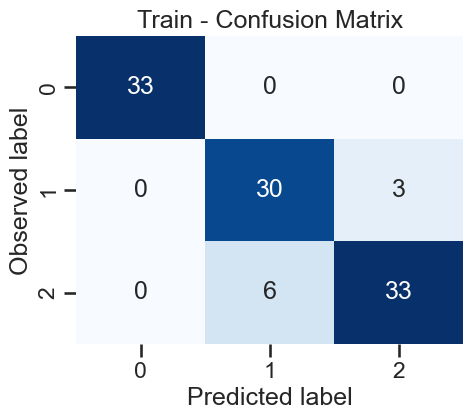

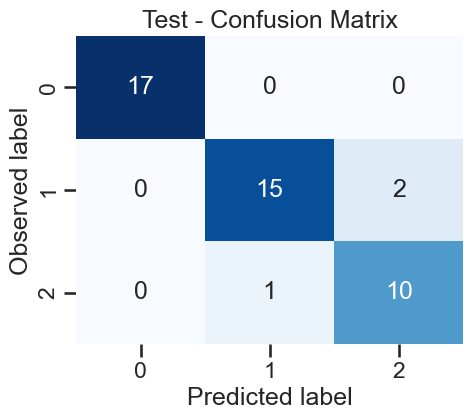

In [9]:
plot_confusion_matrix(y_data, pred_y, title='Train - Confusion Matrix')
plot_confusion_matrix(y_test, pred_y_test, title='Test - Confusion Matrix')

In [10]:
# Print the train/test accuracy
trainacc = np.array([mcmc.accuracy(pred_y[_,:], y_data) for _ in np.arange(pred_y.shape[0])])
testacc = np.array([mcmc.accuracy(pred_y_test[_,:], y_test) for _ in np.arange(pred_y_test.shape[0])])

print('Train accuracy: {:.3f}% ({:.3f})'.format(trainacc.mean(), trainacc.std()))
print('Test accuracy: {:.3f}% ({:.3f})'.format(testacc.mean(), testacc.std()))

Train accuracy: 89.598% (3.536)
Test accuracy: 91.067% (3.803)


In [11]:
def plot_hist(results, param_name):
    posterior_mean = results[param_name].mean()
    print('{:.3f} mean value of posterior'.format(posterior_mean))
    histogram_trace(results[param_name].values)

# use ipywidgets to get a "gui" dropdown to view all the parameters
interact(
    plot_hist, 
    results=fixed(results), 
    param_name=widgets.Dropdown(
        options=results.columns,
        value='w0',
        description='Parameter:',
    )
)
None

interactive(children=(Dropdown(description='Parameter:', options=('w0', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w…

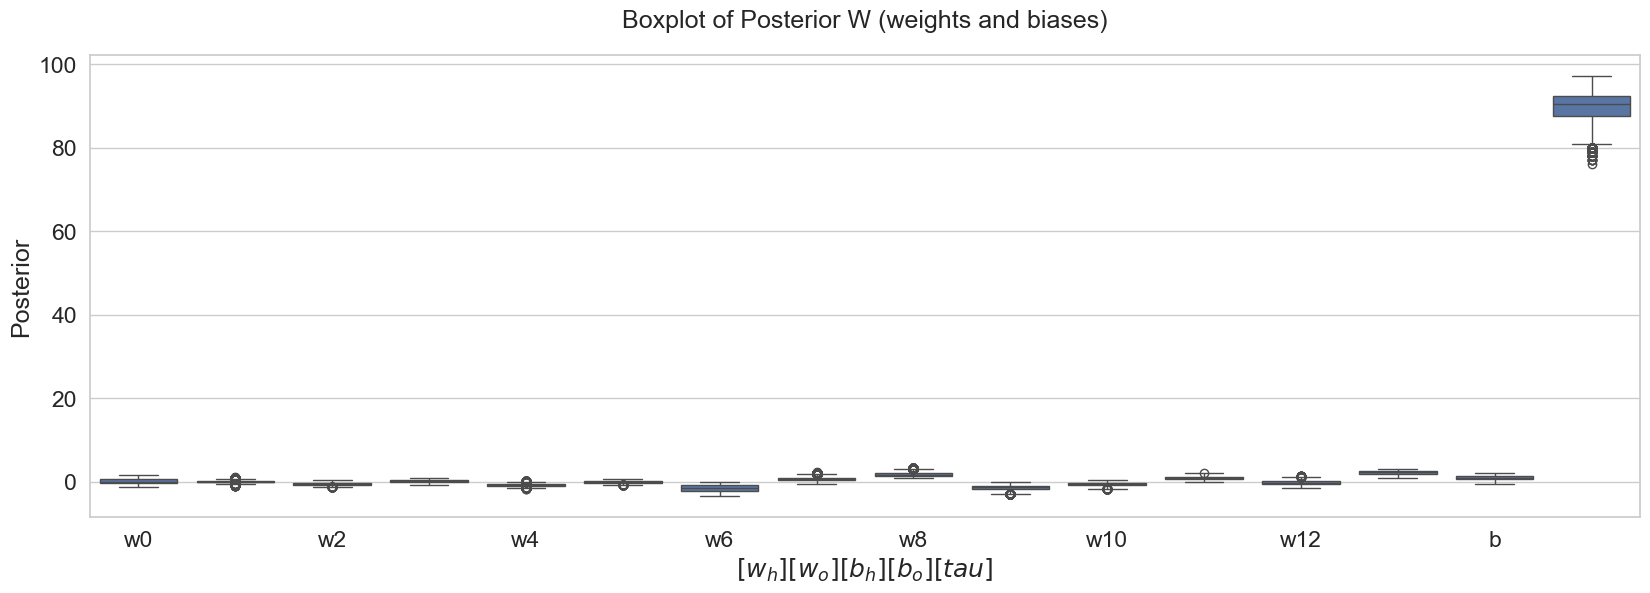

In [12]:
# Visualise all the network weights
boxplot_weights(results,width=20)

# Demonstration of convergence diagnostics
Here we will use the package ArviZ to assess the convergence of the MCMC sampler. To calculate the Rhat convergence diagnostic, we need at least 2 chains. An Rhat value close to 1 indicates convergence.

In [18]:
import arviz as az

np.random.seed(2)

# Create a second MCMC sampler using the same model and data
mcmc_chain2 = MCMC(lm, n_samples, burn_in, x_data, y_data, x_test, y_test)

# Run the second chain
results_chain2, _ = mcmc_chain2.sampler()

# Convert both chains from DataFrames to dictionaries
res_dict = results.to_dict(orient='list')
res_dict_chain2 = results_chain2.to_dict(orient='list')

# Convert the two chains into an ArviZ object.
# This ArviZ version expects the group name "posterior" inside a dictionary,
# not as a keyword argument.
az_results = az.from_dict(
    {
        "posterior": {
            par: np.vstack([res_dict[par], res_dict_chain2[par]])
            for par in res_dict
        }
    }
)

# Show posterior summary statistics and convergence diagnostics
az.summary(az_results)


83.624% were accepted


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w0,-0.1,0.5,-0.82,0.94,16,8,1.15,0.15,0.12
w1,0.1,0.3,-0.41,0.74,13,17,1.13,0.091,0.066
w2,-0.4,0.3,-0.94,-0.01,19,14,1.08,0.071,0.051
w3,0.2,0.3,-0.41,0.59,18,16,1.09,0.074,0.054
w4,-0.8,0.24,-1.2,-0.43,42,85,1.06,0.036,0.028
w5,-0.2,0.3,-0.66,0.24,6,15,1.24,0.11,0.067
w6,-1.2,0.9,-2.8,0.14,4,6,1.44,0.42,0.27
w7,0.4,0.7,-0.67,1.5,6,13,1.20,0.26,0.18
w8,1.5,0.6,0.75,2.8,5,6,1.32,0.25,0.2
w9,-1.7,0.8,-3.1,-0.45,3,8,1.49,0.44,0.3
